<a href="https://colab.research.google.com/github/saptakkashi123-jpg/Syntecxhub---Project-3---Data-Science-Name---Saptak-kashi/blob/main/Covid_19_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
         Date      Country  Confirmed  Recovered  Deaths
0  2020-01-22  Afghanistan          0          0       0
1  2020-01-23  Afghanistan          0          0       0
2  2020-01-24  Afghanistan          0          0       0
3  2020-01-25  Afghanistan          0          0       0
4  2020-01-26  Afghanistan          0          0       0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161568 entries, 0 to 161567
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Date       161568 non-null  object
 1   Country    161568 non-null  object
 2   Confirmed  161568 non-null  int64 
 3   Recovered  161568 non-null  int64 
 4   Deaths     161568 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 6.2+ MB
None

Statistical Summary:
          Confirmed     Recovered         Deaths
count  1.615680e+05  1.615680e+05  161568.000000
mean   7.361569e+05  1.453967e+05   13999.436089
std    3

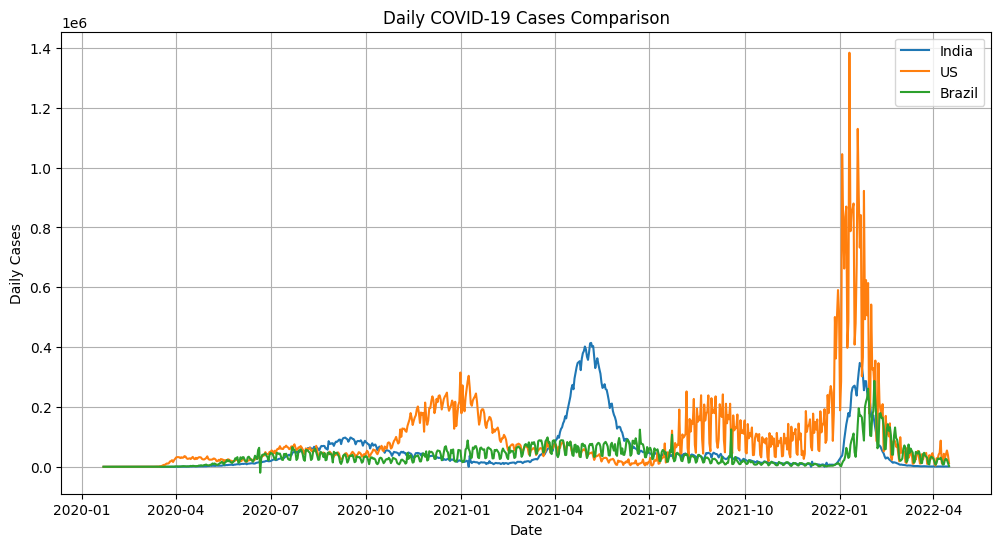

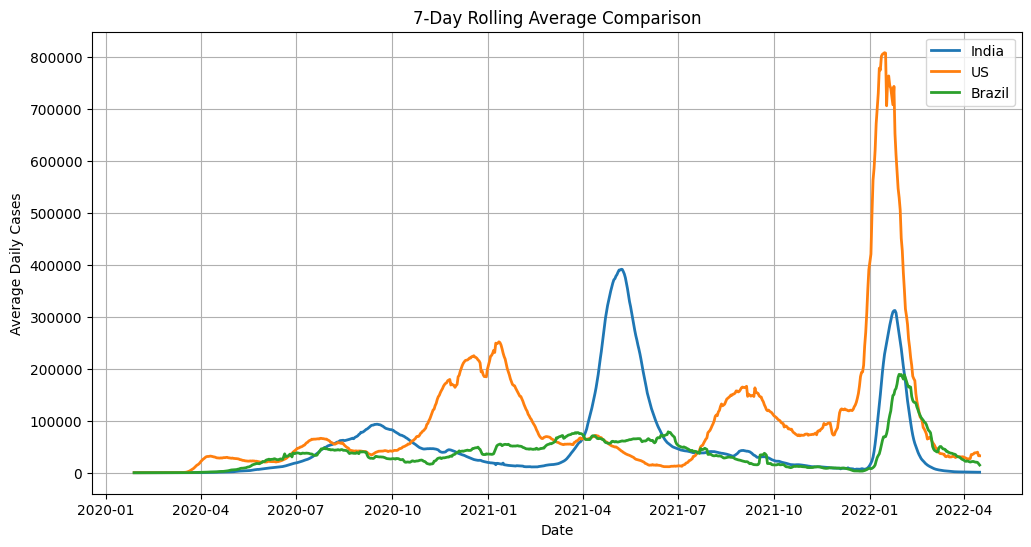


Peak Daily Cases
Country
Brazil     287149.0
India      414188.0
US        1383795.0
Name: Daily Cases, dtype: float64

Growth Rate Sample:
      Country       Date  Daily Cases  Growth Rate
19584  Brazil 2020-01-22          0.0          0.0
19585  Brazil 2020-01-23          0.0          0.0
19586  Brazil 2020-01-24          0.0          0.0
19587  Brazil 2020-01-25          0.0          0.0
19588  Brazil 2020-01-26          0.0          0.0
19589  Brazil 2020-01-27          0.0          0.0
19590  Brazil 2020-01-28          0.0          0.0
19591  Brazil 2020-01-29          0.0          0.0
19592  Brazil 2020-01-30          0.0          0.0
19593  Brazil 2020-01-31          0.0          0.0

Dataset exported successfully as 'covid_analysis.csv'

================== PROJECT CONCLUSION ==================

1. COVID-19 data was successfully loaded and analyzed.
2. Daily new cases were calculated for each selected country.
3. Weekly cases and 7-day rolling averages were computed to smooth 

In [1]:
# Project 3: COVID-19 Data Analysis

# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load Dataset
url = "https://raw.githubusercontent.com/datasets/covid-19/main/data/countries-aggregated.csv"


df = pd.read_csv(url)

print("First 5 Rows:")
print(df.head())

# Step 3: Dataset Information
print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# Step 4: Convert Date Column
df["Date"] = pd.to_datetime(df["Date"])

# Step 5: Select Countries
countries = ["India", "US", "Brazil"]

covid = df[df["Country"].isin(countries)].copy()

# Step 6: Calculate Daily New Cases
covid["Daily Cases"] = covid.groupby("Country")["Confirmed"].diff()
covid["Daily Cases"] = covid["Daily Cases"].fillna(0)

# Step 7: Calculate Weekly Cases
covid["Weekly Cases"] = (
    covid.groupby("Country")["Daily Cases"]
    .rolling(7)
    .sum()
    .reset_index(level=0, drop=True)
)

# Step 8: Calculate 7-Day Rolling Average
covid["Rolling Average"] = (
    covid.groupby("Country")["Daily Cases"]
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

# Step 9: Plot Daily Cases Comparison
plt.figure(figsize=(12,6))

for country in countries:
    data = covid[covid["Country"] == country]
    plt.plot(data["Date"], data["Daily Cases"], label=country)

plt.title("Daily COVID-19 Cases Comparison")
plt.xlabel("Date")
plt.ylabel("Daily Cases")
plt.legend()
plt.grid(True)
plt.savefig("daily_cases_comparison.png")
plt.show()

# Step 10: Plot Rolling Average Comparison
plt.figure(figsize=(12,6))

for country in countries:
    data = covid[covid["Country"] == country]
    plt.plot(data["Date"], data["Rolling Average"], linewidth=2, label=country)

plt.title("7-Day Rolling Average Comparison")
plt.xlabel("Date")
plt.ylabel("Average Daily Cases")
plt.legend()
plt.grid(True)
plt.savefig("rolling_average_comparison.png")
plt.show()

# Step 11: Detect Peak Daily Cases
print("\nPeak Daily Cases")
peak_cases = covid.groupby("Country")["Daily Cases"].max()
print(peak_cases)

# Step 12: Approximate Growth Rate (Basic Reproduction Insight)
covid["Previous Day Cases"] = covid.groupby("Country")["Daily Cases"].shift(1)

covid["Growth Rate"] = covid["Daily Cases"] / covid["Previous Day Cases"]

covid["Growth Rate"] = covid["Growth Rate"].replace([float("inf"), -float("inf")], 0)

covid["Growth Rate"] = covid["Growth Rate"].fillna(0)

print("\nGrowth Rate Sample:")
print(covid[["Country", "Date", "Daily Cases", "Growth Rate"]].head(10))

# Step 13: Export Final Dataset
covid.to_csv("covid_analysis.csv", index=False)

print("\nDataset exported successfully as 'covid_analysis.csv'")

# Step 14: Brief Conclusion
print("\n================== PROJECT CONCLUSION ==================")
print("""
1. COVID-19 data was successfully loaded and analyzed.
2. Daily new cases were calculated for each selected country.
3. Weekly cases and 7-day rolling averages were computed to smooth fluctuations.
4. Daily case trends were compared between India, US, and Brazil.
5. Peak daily case counts were identified for each country.
6. A simple growth-rate metric was calculated to compare changes in daily cases.
7. Charts were exported as PNG images.
8. The processed dataset was exported as 'covid_analysis.csv'.
=========================================================
""")